## Machine Learning Based Student Performance Prediction and Feature Engineering Analysis

###### Name : Samir Shaikh             
###### Branch : Artificial Intelligence and Data Science

### IMPORT REQUIRED LIBRARIES

In [37]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

### Data Understanding

##### 1. LOAD DATASET

In [38]:
df = pd.read_csv("StudentPerformance.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


##### 2. Basic Information

In [39]:
print("Column Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Column Names:
Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours       

##### 3. Checking Missing Values

In [40]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [41]:
print("\nTotal missing values:", df.isnull().sum().sum())


Total missing values: 235


##### 4. Handling Missing Values

In [42]:
# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns

# Categorical columns
cat_cols = df.select_dtypes(include="object").columns

# Fill numerical missing values with median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_19132\4008050100.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


##### 5. Remove Duplicate Records

In [43]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


##### 6. Descriptive Statistics

In [44]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [45]:
df.describe(include="object")  # for categorical columns

C:\Users\HP\AppData\Local\Temp\ipykernel_19132\1486120895.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")  # for categorical columns


,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
count,6607,6607,6607,6607,6607,6607,6607,6607,6607,6607,6607,6607,6607
unique,3,3,2,3,2,3,3,2,3,2,3,3,2
top,Medium,Medium,Yes,Medium,Yes,Low,Medium,Public,Positive,No,High School,Near,Male
freq,3362,3319,3938,3351,6108,2672,4003,4598,2638,5912,3313,3951,3814


### Feature Engineering
##### 1. We will create 5 simple features based on our actual dataset.

In [46]:
# 1. Study and Attendance Index
df["Study_Attendance_Index"] = (
    df["Hours_Studied"] * df["Attendance"]
) / 100                               ## The /100 converts Attendance from a percentage(i.e. 80%) into a proportion(i.e. 0.80).


# 2. Attendance Category
df["Attendance_Category"] = pd.cut(
    df["Attendance"],
    bins=[0, 60, 75, 90, 100],
    labels=["Poor", "Average", "Good", "Excellent"]
)


# 3. Study Hours Category
df["Study_Hours_Category"] = pd.cut(
    df["Hours_Studied"],
    bins=[0, 10, 20, 30, 100],
    labels=["Low", "Medium", "High", "Very High"]
)


# 4. Previous Performance Level
df["Previous_Performance_Level"] = pd.cut(
    df["Previous_Scores"],
    bins=[0, 50, 70, 85, 100],
    labels=["Low", "Average", "Good", "Excellent"]
)


# 5. Academic Risk Score
df["Academic_Risk_Score"] = 0

df.loc[df["Attendance"] < 75, "Academic_Risk_Score"] += 1
df.loc[df["Hours_Studied"] < 15, "Academic_Risk_Score"] += 1
df.loc[df["Previous_Scores"] < 60, "Academic_Risk_Score"] += 1
df.loc[df["Tutoring_Sessions"] == 0, "Academic_Risk_Score"] += 1
df.loc[df["Motivation_Level"] == "Low", "Academic_Risk_Score"] += 1
df.loc[df["Learning_Disabilities"] == "Yes", "Academic_Risk_Score"] += 1         ## Higher score means more academic risk factors are present.

print("Feature engineering completed!")

df.head()

Feature engineering completed!


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Study_Attendance_Index,Attendance_Category,Study_Hours_Category,Previous_Performance_Level,Academic_Risk_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,...,No,High School,Near,Male,67,19.32,Good,High,Good,2
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,No,College,Moderate,Female,61,12.16,Average,Medium,Average,3
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,No,Postgraduate,Near,Male,74,23.52,Excellent,High,Excellent,0
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,No,High School,Moderate,Male,71,25.81,Good,High,Excellent,0
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,No,College,Near,Female,70,17.48,Excellent,Medium,Average,0


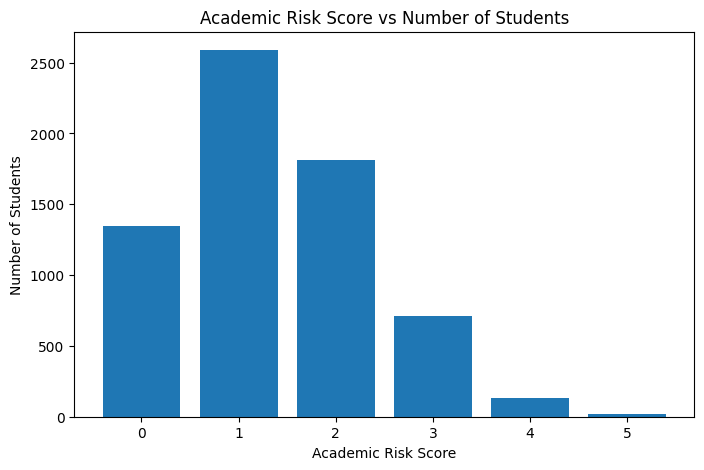

In [47]:
risk_counts = df['Academic_Risk_Score'].value_counts().sort_index() #Number of Students for each Academic_Risk_Score

plt.figure(figsize=(8, 5))

plt.bar(risk_counts.index, risk_counts.values)

plt.title('Academic Risk Score vs Number of Students')
plt.xlabel('Academic Risk Score')
plt.ylabel('Number of Students')

plt.xticks(risk_counts.index)

plt.show()

##### 2. Display New Features

In [48]:
new_features = [
    "Study_Attendance_Index",
    "Attendance_Category",
    "Study_Hours_Category",
    "Previous_Performance_Level",
    "Academic_Risk_Score"
]

df[new_features].head(10)

,Study_Attendance_Index,Attendance_Category,Study_Hours_Category,Previous_Performance_Level,Academic_Risk_Score
0,19.32,Good,High,Good,2
1,12.16,Average,Medium,Average,3
2,23.52,Excellent,High,Excellent,0
3,25.81,Good,High,Excellent,0
4,17.48,Excellent,Medium,Average,0
5,16.72,Good,Medium,Excellent,0
6,24.36,Good,High,Average,1
7,19.50,Good,High,Low,1
8,15.98,Excellent,Medium,Good,1
9,22.54,Excellent,High,Good,1


###### Feature -->	Purpose
###### Study_Attendance_Index -->	Combines study hours and attendance
###### Attendance_Category -->	Converts attendance into Poor/Average/Good/Excellent
###### Study_Hours_Category -->	Groups study hours
###### Previous_Performance_Level -->	Converts previous scores into performance levels
###### Academic_Risk_Score -->	Identifies students with multiple academic risk factors

### Encode Categorical Columns

In [49]:
# Find categorical columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns

print("Categorical columns:")
print(cat_cols)

# Label encode categorical columns
encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))

print("\nCategorical data converted to numbers.")

df.head()

Categorical columns:
Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender', 'Attendance_Category',
       'Study_Hours_Category', 'Previous_Performance_Level'],
      dtype='str')

Categorical data converted to numbers.


C:\Users\HP\AppData\Local\Temp\ipykernel_19132\3544323209.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object", "category"]).columns


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Study_Attendance_Index,Attendance_Category,Study_Hours_Category,Previous_Performance_Level,Academic_Risk_Score
0,23,84,1,0,0,7,73,1,1,0,...,0,1,2,1,67,19.32,2,0,2,2
1,19,64,1,2,0,8,59,1,1,2,...,0,0,1,0,61,12.16,0,2,0,3
2,24,98,2,2,1,7,91,2,1,2,...,0,2,2,1,74,23.52,1,0,1,0
3,29,89,1,2,1,8,98,2,1,1,...,0,1,1,1,71,25.81,2,0,1,0
4,19,92,2,2,1,6,65,2,1,3,...,0,0,2,0,70,17.48,1,2,0,0


### Model 1: Original Features

###### For this dataset, Exam_Score is a continuous numerical value, so we use Random Forest Regression.

##### 1. Create Original Dataset

###### We want Model 1 to use the original features only.

In [50]:
original_columns = [
    "Hours_Studied",
    "Attendance",
    "Parental_Involvement",
    "Access_to_Resources",
    "Extracurricular_Activities",
    "Sleep_Hours",
    "Previous_Scores",
    "Motivation_Level",
    "Internet_Access",
    "Tutoring_Sessions",
    "Family_Income",
    "Teacher_Quality",
    "School_Type",
    "Peer_Influence",
    "Physical_Activity",
    "Learning_Disabilities",
    "Parental_Education_Level",
    "Distance_from_Home",
    "Gender"
]

X_original = df[original_columns]

y = df["Exam_Score"]

print("Original Features:", X_original.shape)
print("Target:", y.shape)

Original Features: (6607, 19)
Target: (6607,)


##### 2. Split Data

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X_original,
    y,
    test_size=0.20,    # 80% training data & 20% testing data
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5285, 19)
Testing data: (1322, 19)


##### 3. Train Model 1

In [52]:
model1 = RandomForestRegressor(
    n_estimators=100,   # Random Forest consists of: 100 decision trees
    random_state=42
)

model1.fit(X_train, y_train)

print("Model 1 trained successfully!")

Model 1 trained successfully!


##### 4. Predict Using Model 1

In [53]:
y_pred1 = model1.predict(X_test)

print("Predicted values:")
print(y_pred1[:10])

Predicted values:
[64.81 66.33 70.33 66.35 66.35 66.71 70.98 67.22 69.7  69.99]


##### 5. Evaluate Model 1

In [54]:
mae1 = mean_absolute_error(y_test, y_pred1)

mse1 = mean_squared_error(y_test, y_pred1)

rmse1 = np.sqrt(mse1)

r21 = r2_score(y_test, y_pred1)

print("Model 1 Results")
print("----------------")
print("MAE  :", mae1)
print("MSE  :", mse1)
print("RMSE :", rmse1)
print("R2   :", r21)

Model 1 Results
----------------
MAE  : 1.1313993948562784
MSE  : 4.881689031770046
RMSE : 2.209454464742382
R2   : 0.6546399715264632


### Model 2: Engineered Features

###### Now we include our five new features.

##### 1. Create Engineered Dataset

In [55]:
engineered_columns = original_columns + [
    "Study_Attendance_Index",
    "Attendance_Category",
    "Study_Hours_Category",
    "Previous_Performance_Level",
    "Academic_Risk_Score"
]

X_engineered = df[engineered_columns]

print("Number of features:", X_engineered.shape[1])      # and as we know y is Exam_Score

Number of features: 24


##### 2. Train-Test Split

In [56]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_engineered,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train2.shape)
print("Testing data:", X_test2.shape)

Training data: (5285, 24)
Testing data: (1322, 24)


##### 3. Train Model 2

In [57]:
model2 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model2.fit(X_train2, y_train2)

print("Model 2 trained successfully!")

Model 2 trained successfully!


##### 4. Predict Using Model 2

In [58]:
y_pred2 = model2.predict(X_test2)

print("Predicted values:")
print(y_pred2[:10])

Predicted values:
[66.75 65.53 70.01 65.99 66.14 66.97 71.37 66.83 69.94 69.45]


##### 5. Evaluate Model 2

In [59]:
mae2 = mean_absolute_error(y_test2, y_pred2)

mse2 = mean_squared_error(y_test2, y_pred2)

rmse2 = np.sqrt(mse2)

r22 = r2_score(y_test2, y_pred2)

print("Model 2 Results")
print("----------------")
print("MAE  :", mae2)
print("MSE  :", mse2)
print("RMSE :", rmse2)
print("R2   :", r22)

Model 2 Results
----------------
MAE  : 1.0908623298033284
MSE  : 4.729899394856278
RMSE : 2.174833187822983
R2   : 0.665378482928022


### Feature Selection

###### Now we select the most useful features.      We will use SelectKBest.

##### 1. Select Important Features

In [60]:
selector = SelectKBest(
    score_func=f_regression,
    k=10
)

X_selected = selector.fit_transform(
    X_engineered,
    y
)

print("Original number of features:", X_engineered.shape[1])
print("Selected number of features:", X_selected.shape[1])

Original number of features: 24
Selected number of features: 10


##### 2. Display Selected Features

In [61]:
selected_features = X_engineered.columns[
    selector.get_support()
]

print("Selected Features:")
print(list(selected_features))

Selected Features:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Previous_Scores', 'Tutoring_Sessions', 'Peer_Influence', 'Study_Attendance_Index', 'Attendance_Category', 'Study_Hours_Category', 'Academic_Risk_Score']


### Train Model Using Selected Features

##### 1. Create Selected Dataset

In [62]:
X_selected = df[selected_features]

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42
)

print("Selected training data:", X_train3.shape)
print("Selected testing data:", X_test3.shape)

Selected training data: (5285, 10)
Selected testing data: (1322, 10)


##### 2. Train Model 3

In [63]:
model3 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model3.fit(X_train3, y_train3)

print("Model 3 trained successfully!")

Model 3 trained successfully!


##### 3. Predict Using Model 3

In [64]:
y_pred3 = model3.predict(X_test3)

print("Predicted values:")
print(y_pred3[:10])

Predicted values:
[64.98 66.83 71.23 65.77 65.15 66.53 70.13 66.36 70.09 69.24]


##### 4. Evaluate Model 3

In [65]:
mae3 = mean_absolute_error(y_test3, y_pred3)

mse3 = mean_squared_error(y_test3, y_pred3)

rmse3 = np.sqrt(mse3)

r23 = r2_score(y_test3, y_pred3)

print("Model 3 Results")
print("----------------")
print("MAE  :", mae3)
print("MSE  :", mse3)
print("RMSE :", rmse3)
print("R2   :", r23)

Model 3 Results
----------------
MAE  : 1.3032705316619841
MSE  : 5.626471590769415
RMSE : 2.3720184634124193
R2   : 0.6019495760283806


### Compare Models
##### 1. Model Comparison

In [66]:
comparison = pd.DataFrame({
    "Model": [
        "Model 1 - Original Features",
        "Model 2 - Engineered Features",
        "Model 3 - Selected Features"
    ],
    
    "MAE": [
        mae1,
        mae2,
        mae3
    ],
    
    "MSE": [
        mse1,
        mse2,
        mse3
    ],
    
    "RMSE": [
        rmse1,
        rmse2,
        rmse3
    ],
    
    "R2 Score": [
        r21,
        r22,
        r23
    ]
})

comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Model 1 - Original Features,1.131399,4.881689,2.209454,0.654640
1,Model 2 - Engineered Features,1.090862,4.729899,2.174833,0.665378
2,Model 3 - Selected Features,1.303271,5.626472,2.372018,0.601950


##### 2. Determine Best Model
For regression:      Best model = 'Lowest MAE' or 'Lowest MSE' or 'Lowest RMSE' or 'Highest R²'

In [67]:
best_model = comparison.loc[
    comparison["R2 Score"].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model       Model 2 - Engineered Features
MAE                              1.090862
MSE                              4.729899
RMSE                             2.174833
R2 Score                         0.665378
Name: 1, dtype: object


### Feature Importance

###### Random Forest provides feature importance directly.

##### 1. Feature Importance

In [68]:
importance = pd.DataFrame({
    "Feature": X_engineered.columns,
    "Importance": model2.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
19,Study_Attendance_Index,0.435823
1,Attendance,0.183443
6,Previous_Scores,0.073284
23,Academic_Risk_Score,0.036043
9,Tutoring_Sessions,0.028268
3,Access_to_Resources,0.028033
2,Parental_Involvement,0.026516
5,Sleep_Hours,0.023981
14,Physical_Activity,0.021897
0,Hours_Studied,0.019713


###### first rows are the features that contributed most strongly to the Random Forest's predictions.

##### 2. Plot Feature Importance

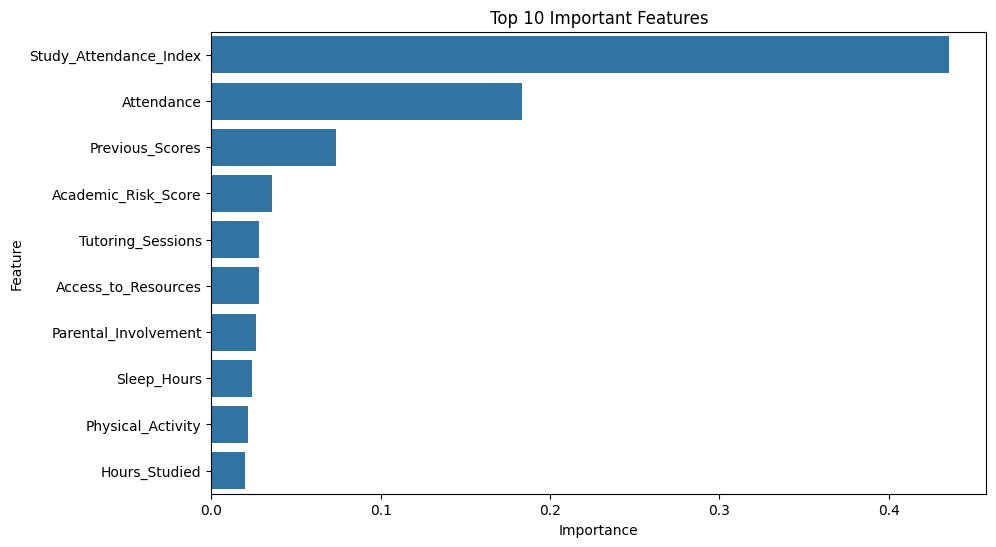

In [69]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

##### 3. Actual vs Predicted

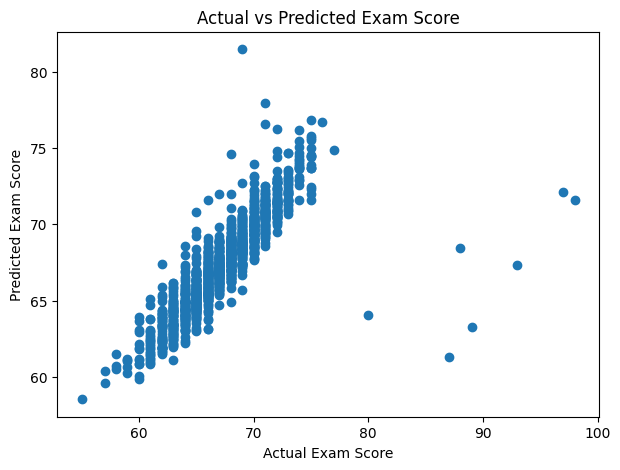

In [70]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test2, y_pred2)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")

plt.title("Actual vs Predicted Exam Score")

plt.show()

Points closer to diagonal = better predictions

### Final Analysis
Automatic Analysis

In [71]:
print("========== FINAL ANALYSIS ==========")

if r22 > r21:
    print("Feature engineering improved the R2 score.")
else:
    print("Feature engineering did not improve the R2 score.")

if r23 > r22:
    print("Feature selection further improved the model.")
else:
    print("Feature selection did not improve the model.")

print("\nMost Important Features:")
print(importance.head(5)["Feature"].tolist())

========== FINAL ANALYSIS ==========
Feature engineering improved the R2 score.
Feature selection did not improve the model.

Most Important Features:
['Study_Attendance_Index', 'Attendance', 'Previous_Scores', 'Academic_Risk_Score', 'Tutoring_Sessions']


In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. To Save correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include="number").corr(), cmap="coolwarm")
plt.tight_layout()
plt.savefig("correlation.png")
plt.close()

# 2. Save actual vs predicted plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test2, y_pred2)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Score")
plt.tight_layout()
plt.savefig("actual_vs_predicted.png")
plt.close()

# 3. To Save model comparison plot
plt.figure(figsize=(8, 4))
sns.barplot(data=comparison, x="Model", y="R2 Score", palette="viridis")
plt.title("Model Comparison (R2 Score)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("model_comparison.png")
plt.close()

print("All 3 images saved successfully!")

All 3 images saved successfully!


C:\Users\HP\AppData\Local\Temp\ipykernel_19132\338273363.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x="Model", y="R2 Score", palette="viridis")
